In [ ]:
from pathlib import Path
from typing import Annotated, Literal
from datetime import datetime

import numpy as np
import pandas as pd

from matplotlib import pyplot as plt
from matplotlib.colors import PowerNorm
from matplotlib.patches import Rectangle, Patch
import matplotlib as mpl
import seaborn as sns

import geopandas
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
import cartopy.crs as ccrs
import matplotlib as mpl
from mpl_sankey import sankey

from IPython.display import display, HTML, Markdown

from climate_health_map.shared import get_logger
from climate_health_map.data.labels import LABELS, Collection, Group, AggTopic, AggAggTopic
from climate_health_map.data.geographies import load_country_infos, load_grid_data, load_annual_population
from climate_health_map.data.export.lancet.loaders import read_base_data
from climate_health_map.data.export.utils import label_group_counts

logger = get_logger('notebook', loglevel='INFO')

In [ ]:
OUTPUT_DIR = Path('../data/exports/lancet/Global')
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

# Load data

In [ ]:
df_countries = load_country_infos()
df_grid = load_grid_data()
df_population = load_annual_population()

In [ ]:
df, df_locations, df_locations_flat, location_groups, df_affiliations, df_affiliations_flat, affiliation_groups = read_base_data(
    source=Path('../data/exports/2026'),
    year_start=1990,
    year_end=2025,
    filter_mai=True,
    filter_rel=True,
    prefilter_affiliations=True,
    prefilter_locations=True,
    fix_locations=True,
    logger=logger.getChild('reader'),
)

df = df.rename(columns={'publication_year': 'Publication year'}).reset_index().set_index('item_id', drop=False)
df_locations = df_locations.reset_index().set_index('item_id', drop=False).join(df[['Publication year', 'Climate category', 'incl_major', 'incl_impacts', 'incl_location', 'incl_affiliation']])
df_affiliations = df_affiliations.reset_index().set_index('item_id', drop=False).join(df[['Publication year', 'Climate category', 'incl_major', 'incl_impacts', 'incl_location', 'incl_affiliation']])

In [ ]:
def label_group_counts(
    df: pd.DataFrame,
    group: Group | AggTopic | AggAggTopic,
    geography_filter: Literal['affiliation', 'location', 'region_affiliation', 'region_location'] | None = None,
    count_primary_class: bool = False,
    threshold: float = 0.5,
) -> tuple[pd.DataFrame, pd.Series, pd.Series]:
    table_index = pd.RangeIndex(start=df['Publication year'].min(), stop=df['Publication year'].max() + 1, step=1, name='Publication year')

    columns = [label.column for label in group.labels if label.column in df.columns]
    mask = (df[columns].notna() & (df[columns] > threshold)).any(axis=1)
    primary = df[mask][columns].fillna(0).idxmax(axis=1)

    if group.collection == Collection.IMPACTS:
        mask &= df['incl_impacts']
    if geography_filter == 'location':
        mask &= df['incl_location']
    if geography_filter == 'affiliation':
        mask &= df['incl_affiliation']
    if geography_filter == 'region_location':
        mask &= df['incl_region_location']
    if geography_filter == 'region_affiliation':
        mask &= df['incl_region_affiliation']

    data = {}
    totals = {}
    for label in group.labels:
        if label.column not in df.columns:
            continue

        extra_mask = (primary == label.column) if count_primary_class else df[label.column] > threshold

        totals[label.name] = df[mask & extra_mask]['item_id'].nunique()
        data[label.name] = df[mask & extra_mask].groupby('Publication year')['item_id'].nunique()

    return (
        pd.DataFrame(data, index=table_index).fillna(0).astype(int),
        pd.Series(totals).fillna(0).astype(int),
        pd.Series(df[mask].groupby('Publication year')['item_id'].nunique(), index=table_index, name='Total').fillna(0).astype(int),
    )


# General counts

In [ ]:
print(df.shape)
print(df_locations.shape)
print(df_affiliations.shape)

In [ ]:
for key in ['incl_major', 'incl_impacts', 'incl_location', 'incl_affiliation']:
    print(key, df[key].sum())

# Annual counts

In [ ]:
annual_counts, totals, annual_totals = label_group_counts(
    df[df['incl_major']], 
    group=LABELS['cat'],
    geography_filter=None,
    count_primary_class=True,
)
pd.options.display.max_columns = 650
pd.options.display.max_rows = 40
joined = annual_counts.join(annual_totals)
cols= joined.columns
share = (joined.T / joined['Total'] * 100).T.set_axis(pd.MultiIndex.from_product([['Annual proportion'], cols]), axis=1)
pct = (joined.pct_change(axis=0)*100).set_axis(pd.MultiIndex.from_product([['Annual growth in %'], cols]), axis=1).replace({np.inf:pd.NA, np.nan: pd.NA})
display(joined.set_axis(pd.MultiIndex.from_product([['Absolute'], cols]), axis=1).join(pct).join(share).style.background_gradient(cmap='Blues', axis=0))
display(totals)
display(totals/totals.sum()*100)

In [ ]:
GR =  1.618  # golden ratio
fig_height = 5
fig, ax = plt.subplots(dpi=150, figsize=(fig_height * GR, fig_height))
annual_counts.plot.bar(stacked=True, ax=ax)#, color=['#fc8d62','#bb22b3','#8da0cb'])
ax.set_ylabel('Number of publications')
ax.set_xlabel('Publication year')
ax.set_title('Estimated number of papers published \non the nexus of climate and health')
ax.set_xticks(np.arange(0, np.sum(ax.get_xlim()), 5))
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
fig.tight_layout()
plt.show(fig)

fig.savefig(OUTPUT_DIR / 'major_category.png')
fig.savefig(OUTPUT_DIR / 'major_category.svg')
fig.savefig(OUTPUT_DIR / 'major_category.pdf')

## Counts with multi-labelling

In [ ]:
annual_counts, totals, annual_totals = label_group_counts(
    df[df['incl_major']], 
    group=LABELS['cat'],
    geography_filter=None,
    count_primary_class=False,
)
pd.options.display.max_columns = 650
pd.options.display.max_rows = 40
joined = annual_counts.join(annual_totals)
cols= joined.columns
share = (joined.T / joined['Total'] * 100).T.set_axis(pd.MultiIndex.from_product([['Annual proportion'], cols]), axis=1)
pct = (joined.pct_change(axis=0)*100).set_axis(pd.MultiIndex.from_product([['Annual growth in %'], cols]), axis=1).replace({np.inf:pd.NA, np.nan: pd.NA})
stats = joined.set_axis(pd.MultiIndex.from_product([['Absolute'], cols]), axis=1).join(pct).join(share)
display(stats.style.background_gradient(cmap='Blues', axis=0))
display(totals)
display(totals/totals.sum()*100)

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 2))

for col in cols:
    axes[0].plot(stats.index, stats[('Absolute', col)], label=col, ls='-' if col == 'Total' else '--')
    axes[0].legend()
    axes[0].set_title('Annual publications (absolute)')

for col in cols:
    axes[1].plot(stats.index, stats[('Annual growth in %', col)].fillna(np.nan), label=col, ls='-' if col == 'Total' else '--')
    axes[1].legend()
    axes[1].set_title('Annual proportional change')

for col in cols:
    if col == 'Total':
        continue
    axes[2].plot(stats.index, stats[('Annual proportion', col)], label=col)
    axes[2].legend()
    axes[2].set_title('Annual share per category')


fig.savefig(OUTPUT_DIR / 'annual_stats.png')
fig.savefig(OUTPUT_DIR / 'annual_stats.svg')
fig.savefig(OUTPUT_DIR / 'annual_stats.pdf')

# Geographic distribution

In [ ]:
try:
    shapes = geopandas.read_file('../data/shapes_2026/WB_GAD_ADM0_complete.shp', encoding='utf-8')
except:
    logger.warning('Official World Bank shapefile missing, falling back to natural_earth default')
    shpfilename = shpreader.natural_earth(
        resolution='10m',
        category='cultural',
        name='admin_0_countries'
    )
    shapes = geopandas.read_file(shpfilename, encoding='utf-8')

# See https://cartopy.readthedocs.io/stable/reference/projections.html

PROJECTION = ccrs.PlateCarree  
AXIS_PROJECTION = ccrs.EqualEarth # Lancert author guideline wants Equal Earth
# #EckertIII

#shapes = adm0shps[adm0shps['ADM0_A3'].isin(countries)]

In [ ]:
def plot(mask = None, bins: list[int] | None = None, show_tables: bool = False, show_distributions: bool = False):
    if mask is None:
        mask = np.ones(len(df_locations), dtype=bool)
    
    cnt_adm0 = df_locations[mask].groupby('iso3')['item_id'].nunique().reset_index().rename(columns={'item_id': 'Count'})
    cnt_latlon = df_locations[mask & (df_locations['feature_code'] != 'PCLI')].groupby(['LAT', 'LON'])['item_id'].nunique().reset_index().rename(columns={'item_id': 'Count'})
    
    cnt_adm0_yr = df_locations[mask].groupby(['iso3','Publication year'])['item_id'].nunique().reset_index().rename(columns={'item_id': 'Count'}).pivot(index='Publication year', columns='iso3', values='Count').fillna(0).astype(int)
    cnt_latlon_yr = df_locations[mask & (df_locations['feature_code'] != 'PCLI')].groupby(['LAT', 'LON', 'Publication year'])['item_id'].nunique().reset_index().rename(columns={'item_id': 'Count'}).pivot(index='Publication year', columns=['LAT','LON'], values='Count').fillna(0).astype(int)

    if show_tables:
        display(Markdown('### Number of publications per country'))
        display(cnt_adm0.transpose())
        display(cnt_latlon.transpose())
    
        display(Markdown('### Number of publications per country per year'))
        display(cnt_adm0_yr.transpose())
        display(cnt_latlon_yr.transpose())

    if show_distributions:
        display(Markdown('### Distribution of sub-national locations'))
        display(Markdown('\n'.join([
            f'* Percentile {p}: {int(np.percentile(cnt_latlon['Count'], p))}'
            for p in range(90, 101, 1)
        ])))
        fig, axes = plt.subplots(1,4, figsize=(15,3))
        cnt_latlon['Count'].hist(bins=100, ax=axes[0])
        cnt_latlon[cnt_latlon['Count'] < np.percentile(cnt_latlon['Count'], 99)]['Count'].hist(bins=50, ax=axes[1])
        cnt_latlon[cnt_latlon['Count'] < np.percentile(cnt_latlon['Count'], 98)]['Count'].hist(bins=20, ax=axes[2])
        cnt_latlon[cnt_latlon['Count'] < np.percentile(cnt_latlon['Count'], 95)]['Count'].hist(bins=10, ax=axes[3])
        plt.show(fig)
    
    fig = plt.figure(dpi=150)#, figsize=(10, 6.5))
    ax = plt.subplot(projection=AXIS_PROJECTION())
    ax.set_title('Locations of studies on the nexus of climate and health', loc='center', fontsize=10)
    ax.set_extent([-180, 180, -90, 90])
    ax.gridlines()
    
    cmap = mpl.colormaps['BuPu']
    norm = mpl.colors.Normalize(vmin=0, vmax=cnt_adm0['Count'].max())
    
    cnt_adm0.set_index('iso3', inplace=True)
    for _, row in shapes.iterrows():
        iso = row['ISO_A3']
        ax.add_geometries(
            [row['geometry']],
            fc=cmap(norm(cnt_adm0.loc[iso, 'Count'])) if iso in cnt_adm0.index else 'None', 
            crs=PROJECTION(), 
            ec='black', 
            lw=0.2,
        )
    
    cbar = fig.colorbar(
        mpl.cm.ScalarMappable(norm=norm, cmap=cmap), 
        ax=ax, orientation='horizontal',
        fraction=0.046, pad=0.04
    )
    cbar.set_label('Number of publications mentioning countries')

    
    if bins is not None:
        # Draw bubbles
        norm = mpl.colors.Normalize(vmin=0, vmax=np.percentile(cnt_latlon['Count'], 98))
        ax.scatter(
            cnt_latlon['LON'], cnt_latlon['LAT'], 
            transform=PROJECTION(), 
            s=norm(cnt_latlon['Count']) * 100,
            alpha=0.7,
            color='#ef8a62',
            zorder=10
        )
        
        # Prepare legend for bubbles
        for bin_i in bins: 
            ax.scatter(
                [],[], 
                transform=PROJECTION(), 
                s=norm(bin_i) * 100,
                label=bin_i,
                alpha=0.7,
                color='#ef8a62',
            )

        leg = ax.legend(title='Number of publications\nmentioning sub-national\nlocations', fontsize=8)
        leg.get_title().set_fontsize('8')
    
    fig.tight_layout()
    
    return fig

## Statistics 1990–2025
These counts include the number of records included in the global indicator that mention a location in Latin America. The analysis has four resolutions: 
* Number of publications per country,
* Number of publications per country and year,
* Number of publications per grid cell and year (2-digits,  [~1km resolution](https://support.oxts.com/hc/en-us/articles/115002885125-Level-of-Resolution-of-Longitude-and-Latitude-Measurements)), and
* Number of publications per grid cell (2-digits,  [~1km resolution](https://support.oxts.com/hc/en-us/articles/115002885125-Level-of-Resolution-of-Longitude-and-Latitude-Measurements)).

The first and last aggregations are plotted.    
For comparison, the distribution and percentiles of counts per grid cell are shown as well.   
The grid cell aggregation is excludion location with 'PCLI' admin codes [(freely associated state)](https://www.geonames.org/export/codes.html)

In [ ]:
fig = plot(show_tables=False, show_distributions=False)

fig.savefig(OUTPUT_DIR / 'geographic_map.png')
fig.savefig(OUTPUT_DIR / 'geographic_map.svg')
fig.savefig(OUTPUT_DIR / 'geographic_map.pdf')

In [ ]:
fig = plot(bins=[1, 10, 50, 100], show_tables=False, show_distributions=True)
fig.savefig(OUTPUT_DIR / 'geographic_map_bubbles.png')
fig.savefig(OUTPUT_DIR / 'geographic_map_bubbles.svg')
fig.savefig(OUTPUT_DIR / 'geographic_map_bubbles.pdf')

## Statistics 2025

In [ ]:
fig = plot(show_tables=False, show_distributions=False, mask=df_locations['Publication year']==2025)

fig.savefig(OUTPUT_DIR / 'geographic_map_2025.png')
fig.savefig(OUTPUT_DIR / 'geographic_map_2025.svg')
fig.savefig(OUTPUT_DIR / 'geographic_map_2025.pdf')

# Regions

In [ ]:
def produce_regional_counts(grouping: str, df_geo: pd.DataFrame, prefix: str):
    display(Markdown(f'### {grouping}'))
    regions = df_geo[grouping].unique()
    
    mask= df['incl_major'] & df['incl_location']
    
    buffer = []
    buffer_totals = []
    for region in regions:
        if type(region) is not str:
            continue
        logger.info(f'Counting for {region}')
        annual_counts, totals, annual_totals = label_group_counts(
            df[mask & df.index.isin(df_geo[df_geo[grouping] == region].index)], 
            group=LABELS['cat'],
            geography_filter='location',
            count_primary_class=True,
        )
        annual_counts['Total'] = annual_totals
        annual_counts.columns = pd.MultiIndex.from_product([[region], annual_counts.columns])
        totals['Total'] = annual_totals.sum()
        totals.index = pd.MultiIndex.from_product([[region], totals.index])
        buffer_totals.append(totals)
        buffer.append(annual_counts)
    regional_counts = pd.concat(buffer, axis=1)
    regional_totals = pd.concat(buffer_totals)
    annual_total = df[mask].groupby('Publication year')['item_id'].nunique()

    annual_group_population = df_population.merge(df_countries, left_on='iso3', right_on='iso3', how='left').groupby([grouping, 'year'])['Population'].sum().reset_index().pivot(index='year', values='Population', columns=grouping)
    annual_group_population.loc[2025] = annual_group_population.loc[2024]  # No data for 2025 yet
    
    prc_pop = regional_counts / annual_group_population.rename_axis(index='Publication year', columns=None) * 100000
    prc_cagr = ((((regional_counts.pct_change(5) + 1) ** (1/5)) - 1) * 100).iloc[5:].replace({np.inf:pd.NA, np.nan: pd.NA})
    prc_pct = regional_counts.pct_change().replace({np.inf:pd.NA, np.nan: pd.NA}) * 100
    prc_per = ((regional_counts.T / regional_counts.T.xs('Total', level=1)).T*100).replace({np.inf:pd.NA, np.nan: pd.NA})
    prc_sha = (regional_counts.T / annual_total*100).replace({np.inf:pd.NA, np.nan: pd.NA}).T
    
    mask = df['incl_major'] & df['incl_location'] & df.index.isin(df_geo[df_geo[grouping].isin(regions)].index)

    display(Markdown(f'#### Totals\nNumber of unique records: {df[mask].index.nunique():,}'))
    display(pd.DataFrame({
        'Total (abs)': regional_totals.astype(int),
        'Total (share per group)':regional_totals/ regional_totals.xs('Total', level=1) * 100,
        'Total (share of total)': regional_totals / df[mask].index.nunique() * 100,
        'Total (share of total, 2021–2025)': regional_counts.loc[2021:2025].sum() / df[mask & (df['Publication year']>=2021) & (df['Publication year']<= 2025)].index.nunique() * 100,
        'Total (share of total, 2016–2020)': regional_counts.loc[2016:2020].sum() / df[mask & (df['Publication year']>=2016) & (df['Publication year']<= 2020)].index.nunique() * 100,
        'Total (per 100k citizens)': prc_pop.mean(axis=0),
        'Total (per 100k citizens, 2021–2025)': prc_pop.loc[2021:2025].mean(axis=0),
        'Total (per 100k citizens, 2016–2020)': prc_pop.loc[2016:2020].mean(axis=0),
    }).T)

    fig, axes = plt.subplots(1, 5, figsize=(25, 2.5), dpi=150)

    for ai, (sub, title) in enumerate([
        (regional_counts, 'Annual counts'),
        (prc_sha, 'Annual shares'),
        (prc_pct, 'Annual growth'),
        (prc_cagr, 'CAGR @ 5yrs'),
        (prc_pop, 'Records per 100k citizens'),
    ]):
        tab = sub.T.xs('Total', level=1).T.fillna(np.nan)
        for col in tab.columns:
            axes[ai].plot(tab.index, tab[col], label=col, lw=1)
            axes[ai].set_title(title)
    axes[-1].legend(bbox_to_anchor=(1.1, 1.05))

    display(fig)
    
    fig.savefig(OUTPUT_DIR / f'regional_counts_{prefix}_{grouping}.png')
    fig.savefig(OUTPUT_DIR / f'regional_counts_{prefix}_{grouping}.svg')
    fig.savefig(OUTPUT_DIR / f'regional_counts_{prefix}_{grouping}.pdf')
    
    fig.clf()
    fig.clear()

    display(Markdown('#### Annual counts'))
    display(regional_counts.astype('Int64'))

    display(Markdown('#### Annual shares per group'))
    display(prc_per)
    
    display(Markdown('#### Annual shares of all'))
    display(prc_sha)

    display(Markdown('#### Annual growth'))
    display(prc_pct)
    
    display(Markdown('#### CAGR @ 5yrs'))
    display(prc_cagr)

    display(Markdown('#### Annual counts by population\nNumbers are normalised to records per 100,000 citizens'))
    display(prc_pop)

## Regions by location

In [ ]:
for grp in [
    'Group (Lancet 2026)', 
    #'Group (WHO 2026)', 
    'Group (HDI 2026)', 
    'Region (WorldBank 2026)', 
    'Income group (WorldBank 2026)',
    #'Lending category (WorldBank 2026)', 
    #'Continent (Name)'
]:
    produce_regional_counts(grp, df_geo=df_locations, prefix='locations')

## Regional counts by affiliation

In [ ]:
for grp in [
    'Group (Lancet 2026)', 
    #'Group (WHO 2026)', 
    'Group (HDI 2026)', 
    'Region (WorldBank 2026)', 
    'Income group (WorldBank 2026)',
    #'Lending category (WorldBank 2026)', 
    #'Continent (Name)'
]:
    produce_regional_counts(grp, df_geo=df_affiliations, prefix='affiliations')

## Affiliation stats
### Number of authors per record

In [ ]:
tab = df_affiliations.reset_index(drop=True).groupby(['Publication year', 'item_id'])['author_id'].nunique().groupby('Publication year').agg(['mean', 'std'])
display(tab.T)
display(df_affiliations.reset_index(drop=True).groupby(['Publication year', 'item_id'])['author_id'].nunique().agg(['mean', 'std']).T)

fig, ax = plt.subplots(dpi=150, figsize=(15,3))
ax.errorbar(tab.index, tab['mean'], tab['std'], linestyle='None', marker='^')
tab['mean'].plot(ax=ax)
ax.set_title('Average number of authors (with std) per record')

fig.savefig(OUTPUT_DIR / 'affiliation_means.png')
fig.savefig(OUTPUT_DIR / 'affiliation_means.svg')
fig.savefig(OUTPUT_DIR / 'affiliation_means.pdf')

# Climate impacts

In [ ]:
df_study_grid = df_locations.set_index(['LAT', 'LON']).join(df_grid.set_index(['LAT', 'LON']))
mask_attr_studies = df_study_grid['incl_impacts'] & df_study_grid['incl_location'] & df_study_grid['grid_attributable']

display(Markdown(f'''
* Relevant records: {df[df['incl_major']]['item_id'].nunique():,}
* Relevant with location: {df[df['incl_location'] & df['incl_major']]['item_id'].nunique():,}
* Relevant records and category impacts: {df[df['incl_major'] & (df['cat|2']>0.5)]['item_id'].nunique():,}
* Relevant on impacts: {df[df['incl_impacts'] & df['incl_major']]['item_id'].nunique():,}
* Relevant on impacts with location: {df[df['incl_location'] & df['incl_major'] & df['incl_impacts']]['item_id'].nunique():,}
* Records on impacts with location in attributable cell: {df_study_grid[mask_attr_studies]['item_id'].nunique():,}
* Records on impacts with location in non-attributable cell: {df_study_grid[df_study_grid['incl_impacts'] & df_study_grid['incl_location'] & ~df_study_grid['grid_attributable']]['item_id'].nunique():,}
'''))

## Label counts

In [ ]:
pd.options.display.max_columns = 650
pd.options.display.max_rows = 40

incl_ids = df_study_grid[mask_attr_studies]['item_id'].unique()

for key in [
    'driver', 
    'event', 
    'health', 
    'expose',
    'attr',
    'sector', 
    'keywords',
   #'topic-agg',
    'topic-agg-agg',
]:
    group = LABELS[key]

    display(Markdown(f'### {group.name}'))
    
    annual_counts, totals, annual_totals = label_group_counts(
        #df[df.index.isin(incl_ids)], 
        df[df['incl_impacts'] & df['incl_major'] & df['incl_location']],
        group=group,
        geography_filter=None,
        count_primary_class=False,
    )

    joined = annual_counts.join(annual_totals)
    cols= joined.columns
    share = (joined.T / joined['Total'] * 100).T.set_axis(pd.MultiIndex.from_product([['Annual proportion'], cols]), axis=1)
    pct = (joined.pct_change(axis=0)*100).set_axis(pd.MultiIndex.from_product([['Annual growth in %'], cols]), axis=1).replace({np.inf:pd.NA, np.nan: pd.NA})
    stats = joined.set_axis(pd.MultiIndex.from_product([['Absolute'], cols]), axis=1).join(pct).join(share)
    display(pd.DataFrame({
        'Totals': totals,
        'Shares (sum)': totals/totals.sum()*100,
        'Shares (count)': totals/annual_totals.sum()*100,
    }).T)
    display(stats.style.background_gradient(cmap='Blues', axis=0))

## Geostats

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(1,3, dpi=150, figsize=(16,5), subplot_kw={'projection': ccrs.EqualEarth(central_longitude=30)})


def plot(ax, title, field, data):
    data = df_grid.merge(data, left_on=['LAT', 'LON'], right_on=['LAT', 'LON'], suffixes=('_x', ''), how='outer')
    lat = list(data['LAT'].unique())
    lon = list(data['LON'].unique())
    grid = np.empty((len(lat), len(lon)))
    grid[:] = np.nan
    
    for _, row in data.iterrows():
       grid[lat.index(row['LAT']), lon.index(row['LON'])] = row[field] if not pd.isna(row[field]) else np.nan
    
    mesh = ax.pcolormesh(
         lon, lat, grid,
        cmap=mpl.colormaps.get_cmap('Greens'),
        norm=mpl.colors.LogNorm(),
        transform=ccrs.PlateCarree()
    )
    
    ax.coastlines(lw=0.2)
    
    fig.colorbar(mesh, ax=ax, location='bottom', shrink=0.75, pad=0.05, label=title)

pop = df_grid[df_grid['is_land']==True].groupby(['LAT','LON']).first()['population']
pub = df_study_grid[(df_study_grid['is_land']==True) & mask_attr_studies].groupby(['LAT','LON'])['item_id'].nunique()
ppp = (pub / pop * 1000000).reset_index().replace({np.inf: np.nan, pd.NA: np.nan})
ppp = ppp[ppp['LAT'].notna() & ppp['LON'].notna() & ppp[0].notna()]

plot(ax1, 'Number of citizens', 'population', pop.reset_index())
plot(ax2, 'Number of publications', 'item_id', pub.reset_index())
plot(ax3, 'Publications per 1,000,000 inhabitants', 0, ppp)#ppp.set_index(['LAT','LON']).clip(0, 500).reset_index())


fig.tight_layout()

fig.savefig(OUTPUT_DIR / 'global_distribution.png')
fig.savefig(OUTPUT_DIR / 'global_distribution.svg')
fig.savefig(OUTPUT_DIR / 'global_distribution.pdf')

## Attributions on geographic map

In [ ]:
 def plot_da(pax, da_var, colors=['#fee391','#b2182b','#ef8a62','#fddbc7','#f7f7f7','#d1e5f0','#67a9cf','#2166ac',"#40004b"], vmin=-4, vmax=4):
    pax.coastlines(lw=0.1)

    bn = np.ones((len(df_grid.LAT.unique()), len(df_grid.LON.unique())))
    mesh = pax.pcolormesh(
        df_grid.LON.unique(),#-degrees*0.5,
        df_grid.LAT.unique(),#-degrees*0.5,
        bn,
        cmap = mpl.colors.ListedColormap(["#e0e0e0"]),
        transform=ccrs.PlateCarree(),
    )
    
    n = np.array(df_grid[da_var]).reshape(len(df_grid.LAT.unique()), len(df_grid.LON.unique()))
    mesh = pax.pcolormesh(
        df_grid.LON.unique(),
        df_grid.LAT.unique(),
        n,
        cmap=mpl.colors.ListedColormap(colors),
        vmin=vmin, vmax=vmax,
        transform=ccrs.PlateCarree(),
    )
    
    return mesh

In [ ]:
title_fs = 10
s_precip_colors = ['#ef8a62','#f7f7f7','#67a9cf']

## Different arrangement

############################################################
## Set up figure
fig = plt.figure(figsize=(7.2,8), dpi=150, constrained_layout=False)
w_r = [1, .05]

h_r = [1, 1, 1]
gs = fig.add_gridspec(3, 2, width_ratios=w_r, height_ratios=h_r, figure=fig, wspace=0.1, hspace=0.3)

############################################################
## Plot Temperature

axa = plt.subplot(gs[0,0], projection=ccrs.EqualEarth())
axa.set_title('a. Attributable trends in temperature', fontsize=title_fs, loc="left" )
precip_colors = ['#fee391','#b2182b','#ef8a62','#fddbc7','#f7f7f7','#d1e5f0','#67a9cf','#2166ac',"#40004b"]
mesh = plot_da(axa, 'temp_da', s_precip_colors[::-1], -1, 1)

############################################################
## Plot Precip

axa = plt.subplot(gs[1,0], projection=ccrs.EqualEarth())
axa.set_title('b. Attributable trends in precipitation', fontsize=title_fs, loc="left" )
precip_colors = ['#fee391','#b2182b','#ef8a62','#fddbc7','#f7f7f7','#d1e5f0','#67a9cf','#2166ac',"#40004b"]
mesh = plot_da(axa, 'precip_da', s_precip_colors, -1, 1)
ms = mesh

############################################################
## Plot colorbar
frac = 0.8
cax = plt.subplot(gs[:2, 1])
cax.axis('off')

cax = cax.inset_axes([0.0, (1-frac)*0.5, 1, frac])
cbar = plt.colorbar(
    mesh, cax=cax, 
    ticks=np.linspace(-.8,.8,3),
)
cax.set_yticklabels(["Attributably\nwarmer", "No attributable\nchange", "Attributably\ncooler"], fontsize=7)

cax2 = cax.twinx()

cax2.set_ylim(-1,1)
cax2.set_yticks(np.linspace(-.8,.8,3))
cax2.set_yticklabels(["Attributably\ndrier", "No attributable\nchange", "Attributably\nwetter"], fontsize=7)

############################################################
## Plot paper density

ax = plt.subplot(gs[2,0],projection=ccrs.EqualEarth())
ax.set_title('c. Density of impact studies', fontsize=title_fs, loc="left" )
ax.coastlines(lw=0.2)

grid = df_study_grid[mask_attr_studies].groupby(['LAT', 'LON'])['item_id'].nunique().rename('Number of studies')
grid = df_grid.set_index(['LAT', 'LON']).join(grid).reset_index()
grid.loc[grid['is_land'] != True, 'Number of studies'] = np.nan
grid['perpop'] = grid['Number of studies'] / (grid['population'].replace({0:np.nan}) / 1000000)
display(grid.describe())

shape = (len(grid.LAT.unique()), len(grid.LON.unique()))
n = np.array(grid['Number of studies']).reshape(shape)#.clip(0, 1000)
mesh=ax.pcolormesh(
    grid.LON.unique(), 
    grid.LAT.unique(), 
    n, 
    cmap=mpl.colormaps.get_cmap('Greens'),
    norm=mpl.colors.LogNorm(),
    transform=ccrs.PlateCarree()
)
cax = plt.subplot(gs[2,1])

cbar = plt.colorbar(mesh, orientation="vertical", cax=cax)
cax.tick_params(labelsize=7)
cbar.set_label("Climate health impact\nstudies per 10,000 km²", fontsize=7)


fig.savefig(OUTPUT_DIR / 'attribution.png')
fig.savefig(OUTPUT_DIR / 'attribution.svg')
fig.savefig(OUTPUT_DIR / 'attribution.pdf')

COPY OF OLD CODE; NEEDS MIGRATION

```python
tmp = df_trends.copy()
tmp['temp'] = np.nan
tmp.loc[tmp['temp_da'].isin([2,3]), 'temp'] = 0
tmp.loc[tmp['temp_da'].isin([0,1,4,-1,-4]), 'temp'] = 1
tmp.loc[tmp['temp_da'].isin([-2,-3]), 'temp'] = 2
tmp['prec'] = np.nan
tmp.loc[tmp['precip_da'].isin([2,3]), 'prec'] = 0
tmp.loc[tmp['precip_da'].isin([0,1,4,-1,-4]), 'prec'] = 1
tmp.loc[tmp['precip_da'].isin([-2,-3]), 'prec'] = 2

fig, (ax1, ax2, ax3) = plt.subplots(1,3, dpi=150, figsize=(16,7), subplot_kw={'projection': ccrs.EckertIII(central_longitude=30)})

lat, lon, grid = frame2grid(tmp, 'temp')
ax1.coastlines(lw=0.2)
ax1.pcolormesh(lon, lat, np.ones((len(lat), len(lon))), cmap = mpl.colors.ListedColormap(["#e0e0e0"]), transform=ccrs.PlateCarree())
mesh = ax1.pcolormesh(lon, lat, grid, vmin=0, vmax=2, cmap=mpl.colors.ListedColormap(['#ef8a62','#f7f7f7','#67a9cf']), transform=ccrs.PlateCarree())
bar = fig.colorbar(mesh, ax=ax1, location='bottom', shrink=0.75, pad=0.05, label='Attributable temperature trends')
bar.set_ticks(ticks=[0,1,2], labels=['Warmer', 'Not attributable', 'Cooler'], fontsize=9)

lat, lon, grid = frame2grid(tmp, 'prec')
ax2.coastlines(lw=0.2)
ax2.pcolormesh(lon, lat, np.ones((len(lat), len(lon))), cmap = mpl.colors.ListedColormap(["#e0e0e0"]), transform=ccrs.PlateCarree())
mesh = ax2.pcolormesh(lon, lat, grid, vmin=0, vmax=2, cmap=mpl.colors.ListedColormap(['#ef8a62','#f7f7f7','#67a9cf']), transform=ccrs.PlateCarree())
bar = fig.colorbar(mesh, ax=ax2, location='bottom', shrink=0.75, pad=0.05, label='Attributable precipitation trends')
bar.set_ticks(ticks=[0,1,2], labels=['Wetter', 'Not attributable', 'Drier'], fontsize=9)

lat, lon, grid = frame2grid(ppp.set_index(['LAT','LON']).clip(0, 500).reset_index(), 0)
ax3.coastlines(lw=0.2)
mesh = ax3.pcolormesh(lon, lat, grid, cmap=mpl.colormaps.get_cmap('Greens'), norm=mpl.colors.LogNorm(), transform=ccrs.PlateCarree())
fig.colorbar(mesh, ax=ax3, location='bottom', shrink=0.75, pad=0.05, label='Publications per 1,000,000 inhabitants')

fig.tight_layout()
plt.show(fig)
```
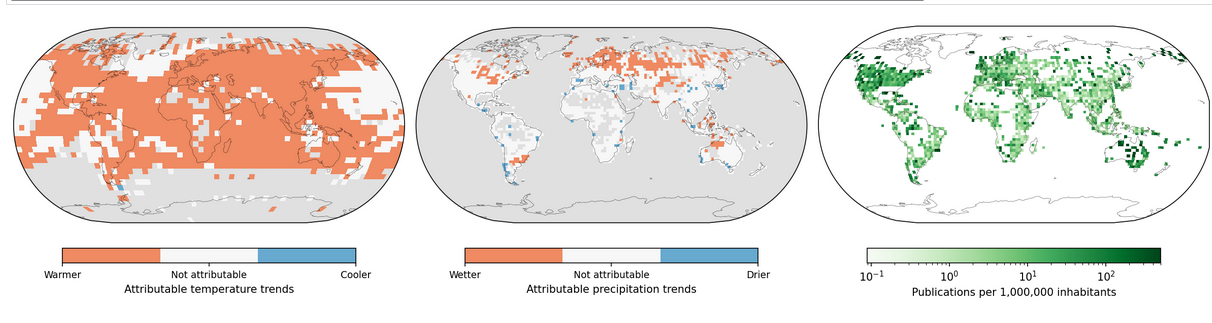

## Exposed people

In [ ]:
df_exposed = pd.DataFrame({
    'Population (in M)': df_countries.groupby('Group (Lancet 2026)')['Population (Lancet, 2025)'].sum() / 1000000,
    'Number of studies': df_study_grid[mask_attr_studies].groupby('Group (Lancet 2026)')['item_id'].nunique(),
})
df_exposed['Studies per million citizens exposed'] = df_exposed['Number of studies']  / df_exposed['Population (in M)']
df_exposed

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10,5), dpi=150)
W = 0.3
axes[0].barh(np.arange(len(df_exposed.index))+(W/2), df_exposed['Number of studies'], height=W, label='Number of studies')
axes[0].barh(np.arange(len(df_exposed.index))-(W/2), df_exposed['Population (in M)'], height=W, label='Population in M')
axes[0].set_yticks(range(df_exposed.shape[0]))
axes[0].set_yticklabels(df_exposed.index)
axes[0].legend()

axes[1].set_title('Studies per million inhabitants exposed', fontsize=10)
axes[1].barh(df_exposed.index, df_exposed['Studies per million citizens exposed'], label='Studies per million citizens', height=0.5)
axes[1].set(yticklabels=[])

fig.savefig(OUTPUT_DIR / 'affected.png')
fig.savefig(OUTPUT_DIR / 'affected.svg')
fig.savefig(OUTPUT_DIR / 'affected.pdf')

## Sankeys

In [ ]:
df_study_grid[mask_attr_studies].merge(df.reset_index(drop=True), left_on='item_id', right_on='item_id', suffixes=('_x', ''))

In [ ]:
ATTRIBUTABLE = {
    'driver|1': ('Changes in temperature', 'temp_da'),
    #'climateDrivers|2': 'Seasonal Change',
    'driver|3': ('Changes in precipitation', 'precip_da'),
    #'climateDrivers|4': 'Sea-level rise',
    #'climateDrivers|5': 'Climate Change (unspecified) ',
    #'climateDrivers|7': 'Other meteorological variables',
    #'climateDrivers|6': 'Changes in humidity'},
}

# 'driver',     'event',     'health',     'expose',    'attr',    'sector',     'keywords',
tab = df_study_grid.merge(df.reset_index(drop=True), left_on='item_id', right_on='item_id', suffixes=('_x', ''))

mask_base = tab['incl_impacts'] & tab['incl_location'] & (tab['is_land'] == True)
mask_attr = tab['grid_attributable'] == True

lab1 = LABELS['driver']
lab2 = LABELS['health']

n_a = tab[mask_base & mask_attr]['item_id'].nunique()
n_na = tab[mask_base & ~mask_attr]['item_id'].nunique()

data = []
for i, label1 in enumerate(lab1.labels):
    name1 = label1.name
    key1 = label1.column
    if key1 not in tab: continue
    print(name1, key1)
    m1 = (tab[key1] >= 0.5) 
    n1 = tab[m1]['openalex_id'].nunique()

    for j, label2 in enumerate(lab2.labels):
        name2 = label2.name
        key2 = label2.column
        if key2 not in tab: continue
        m2 = (tab[key2] >= 0.5)
        n2 = tab[m2]['item_id'].nunique()
        
        if key1 in ATTRIBUTABLE:
            data.append([
                tab[mask_base & mask_attr & m1 & m2]['item_id'].nunique(),
                f'Attributable ({n_a:,})',
                f'{name1} ({n1:,})',
                f'{name2} ({n2:,})',
            ])
            data.append([
                tab[mask_base & ~mask_attr & m1 & m2]['item_id'].nunique(),
                f'Not attributable ({n_na:,})',
                f'{name1} ({n1:,})',
                f'{name2} ({n2:,})',
            ])
        else:
            data.append([
                tab[mask_base & m1 & m2]['item_id'].nunique(),
                'NA',
                f'{name1} ({n1:,})',
                f'{name2} ({n2:,})',
            ])

sdf = pd.DataFrame(data, columns=['Weight', 'In area where trend is', lab1.name, lab2.name])

fig = plt.figure(figsize=(7.4, 7), dpi=150)
sankey(sdf, cmap=plt.get_cmap('viridis'), labels_size=8, titles_size=10)
plt.tight_layout()

fig.savefig(OUTPUT_DIR / 'sankey.png')
fig.savefig(OUTPUT_DIR / 'sankey.svg')
fig.savefig(OUTPUT_DIR / 'sankey.pdf')